# Foundations of Deep Learning: Perceptron Implementation Notebook

This Jupyter notebook provides hands-on implementation of the perceptron concepts discussed in the slides for the generative AI course. We'll implement the perceptron from scratch, explore its limitations with the XOR problem, and implement backpropagation for neural networks.

### Table of Contents

* Basic Perceptron Implementation
* AND Gate Verification and Learning
* XOR Problem and Multilayer Perceptron Solution
* Backpropagation Implementation from Scratch

# Basic Perceptron Implementation
Let's start by implementing a Perceptron class that follows the mathematical model presented in the slides.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

class Perceptron:
    def __init__(self, weights=None, threshold=0.0):
        """
        Initialize a perceptron with given weights and threshold.

        Parameters:
        - weights: array of input weights
        - threshold: activation threshold (theta)
        """
        self.weights = weights
        self.threshold = threshold

    def predict(self, inputs):
        """
        Make a prediction using the perceptron model.

        Parameters:
        - inputs: input values for the perceptron

        Returns:
        - 1 if the weighted sum is >= threshold, 0 otherwise
        """
        # Calculate weighted sum of inputs
        weighted_sum = np.dot(inputs, self.weights)

        # Apply threshold activation function
        if weighted_sum >= self.threshold:
            return 1
        else:
            return 0

    def train(self, training_inputs, labels, learning_rate=0.1, epochs=100):
        """
        Train the perceptron using the perceptron learning algorithm.

        Parameters:
        - training_inputs: array of training input data
        - labels: array of target labels (0 or 1)
        - learning_rate: learning rate for weight updates
        - epochs: maximum number of training iterations

        Returns:
        - list of errors per epoch
        """
        # Initialize weights if not provided
        if self.weights is None:
            self.weights = np.random.rand(len(training_inputs[0]))

        errors = []

        # Training loop
        for epoch in range(epochs):
            total_error = 0

            # Iterate through all training examples
            for inputs, label in zip(training_inputs, labels):
                # Make prediction
                prediction = self.predict(inputs)

                # Calculate error
                error = label - prediction
                total_error += abs(error)

                # Update weights if error exists
                if error != 0:
                    self.weights += learning_rate * error * inputs

            errors.append(total_error)

            # Early stopping if perfect classification
            if total_error == 0:
                print(f"Converged at epoch {epoch+1}")
                break

        return errors


# AND Gate Verification and Learning
Let's verify the AND gate implementation using the weights given in the slides.

In [4]:
def verify_gate(perceptron, gate_name="Gate"):
    """Verify a logical gate using a perceptron"""
    # Truth table inputs
    inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

    # For AND gate
    if gate_name == "AND":
        expected = np.array([0, 0, 0, 1])
    # For OR gate
    elif gate_name == "OR":
        expected = np.array([0, 1, 1, 1])
    # For NAND gate
    elif gate_name == "NAND":
        expected = np.array([1, 1, 1, 0])
    # For XOR gate
    elif gate_name == "XOR":
        expected = np.array([0, 1, 1, 0])

    # Test predictions
    print(f"{gate_name} Gate Truth Table:")
    print("x1 | x2 | Expected | Predicted")
    print("----------------------------")

    correct = 0
    for i, input_vals in enumerate(inputs):
        pred = perceptron.predict(input_vals)
        result = "✓" if pred == expected[i] else "✗"
        print(f" {input_vals[0]} |  {input_vals[1]} |    {expected[i]}     |    {pred}     | {result}")
        if pred == expected[i]:
            correct += 1

    accuracy = correct / len(inputs) * 100
    print(f"Accuracy: {accuracy}%")
    return accuracy == 100



In [3]:
# Verify AND gate with weights from slides
and_weights = np.array([0.5, 0.5])  # From slide
and_threshold = 0.7                 # From slide
and_perceptron = Perceptron(weights=and_weights, threshold=and_threshold)

verify_gate(and_perceptron, "AND")

AND Gate Truth Table:
x1 | x2 | Expected | Predicted
----------------------------
 0 |  0 |    0     |    0     | ✓
 0 |  1 |    0     |    0     | ✓
 1 |  0 |    0     |    0     | ✓
 1 |  1 |    1     |    1     | ✓
Accuracy: 100.0%


True

Now let's use the perceptron learning algorithm to learn the weights for the AND gate:

Training perceptron for OR gate...
Converged at epoch 1


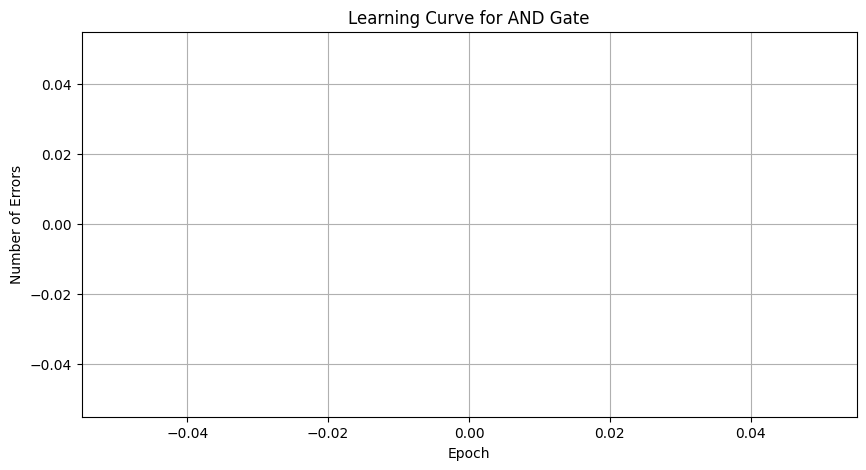


Learned Weights:
w₁ = 0.9329
w₂ = 0.5644
Threshold = 0.5000
OR Gate Truth Table:
x1 | x2 | Expected | Predicted
----------------------------
 0 |  0 |    0     |    0     | ✓
 0 |  1 |    1     |    1     | ✓
 1 |  0 |    1     |    1     | ✓
 1 |  1 |    1     |    1     | ✓
Accuracy: 100.0%


In [13]:
def learn_and_gate():
    """Learn the weights for AND gate using perceptron learning algorithm"""
    # Initialize perceptron with random weights
    perceptron = Perceptron(weights=np.random.rand(2), threshold=0.5)

    # AND gate truth table
    inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    expected = np.array([0, 0, 0, 1])

    # Train the perceptron
    print("Training perceptron for AND gate...")
    errors = perceptron.train(inputs, expected, learning_rate=0.1, epochs=100)

    # Visualize training
    plt.figure(figsize=(10, 5))
    plt.plot(errors)
    plt.title('Learning Curve for AND Gate')
    plt.xlabel('Epoch')
    plt.ylabel('Number of Errors')
    plt.grid(True)
    plt.show()

    # Verify results
    print("\nLearned Weights:")
    print(f"w₁ = {perceptron.weights[0]:.4f}")
    print(f"w₂ = {perceptron.weights[1]:.4f}")
    print(f"Threshold = {perceptron.threshold:.4f}")

    verify_gate(perceptron, "AND")

    return perceptron

# Learn AND gate
learned_and_perceptron = learn_and_gate()

# XOR Problem and Multilayer Perceptron Solution
The XOR gate is a classic problem that cannot be solved by a single perceptron. We'll implement a solution using multiple perceptrons arranged in layers.

In [16]:
def implement_xor_with_gates():
    """
    Implement XOR using a multilayer perceptron:
    Layer 1: OR gate and NAND gate
    Layer 2: AND gate combining the outputs

    Students will fill in the weights for each gate.
    """
    # Template for students to complete
    gates = {
        # STUDENT TASK: Fill in appropriate weights and thresholds
        'or_gate': Perceptron(weights=None, threshold=None),    # FILL IN
        'nand_gate': Perceptron(weights=None, threshold=None),  # FILL IN
        'and_gate': Perceptron(weights=None, threshold=None)    # FILL IN
    }


    # XOR truth table
    inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    expected_xor = np.array([0, 1, 1, 0])

    # Test the XOR implementation
    print("XOR Implementation Test:")
    print("x1 | x2 | Expected | Predicted")
    print("----------------------------")

    correct = 0
    try:
        for i, input_vals in enumerate(inputs):
            # Step 1: Get outputs from first layer
            or_output = gates['or_gate'].predict(input_vals)
            nand_output = gates['nand_gate'].predict(input_vals)

            # Step 2: Feed to second layer (AND gate)
            combined_input = np.array([or_output, nand_output])
            xor_output = gates['and_gate'].predict(combined_input)

            # Check result
            result = "✓" if xor_output == expected_xor[i] else "✗"
            print(f" {input_vals[0]} |  {input_vals[1]} |    {expected_xor[i]}     |    {xor_output}     | {result}")
            if xor_output == expected_xor[i]:
                correct += 1

        accuracy = correct / len(inputs) * 100
        print(f"Accuracy: {accuracy}%")
    except (TypeError, AttributeError):
        print("\n[⚠️ Error]: It seems some weights or thresholds are not set yet (None).")
        print("[💡 Hint]: To implement XOR, you need to set up appropriate weights for three gates:")
        print("  1. OR Gate (detects if any input is '1')")
        print("  2. NAND Gate (detects if inputs are 'not both 1')")
        print("  3. AND Gate (combines the outputs of OR and NAND)")
        print("\nTry setting weights like np.array([0.5, 0.5]) and threshold like 0.5, then adjust accordingly.\n")

    return gates

# Example solution (instructors can uncomment this)
"""
# Solution:
gates = {
    'or_gate': Perceptron(weights=np.array([0.5, 0.5]), threshold=0.3),
    'nand_gate': Perceptron(weights=np.array([-0.5, -0.5]), threshold=-0.7),
    'and_gate': Perceptron(weights=np.array([0.5, 0.5]), threshold=0.7)
}
"""

# Try the XOR implementation (students should complete)
xor_gates = implement_xor_with_gates()

XOR Implementation Test:
x1 | x2 | Expected | Predicted
----------------------------


TypeError: unsupported operand type(s) for *: 'int' and 'NoneType'

# Backpropagation Implementation from Scratch
Now let's implement a neural network with backpropagation to solve the XOR problem end-to-end

Training neural network on XOR problem...
Epoch 0, Loss: 0.250063
Epoch 10000, Loss: 0.250000
Epoch 20000, Loss: 0.250000
Epoch 30000, Loss: 0.250000
Epoch 40000, Loss: 0.250000
Epoch 50000, Loss: 0.250000
Epoch 60000, Loss: 0.250000
Epoch 70000, Loss: 0.250000
Epoch 80000, Loss: 0.250000
Epoch 90000, Loss: 0.250000


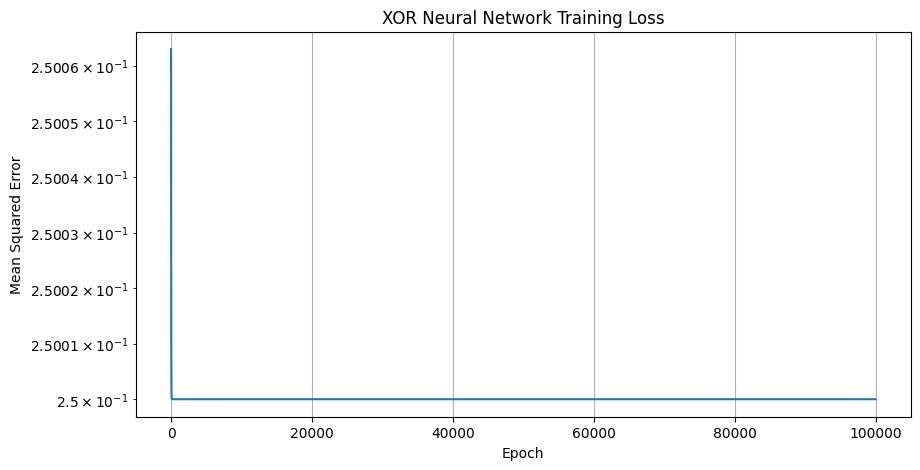


Neural Network XOR Results:
x1 | x2 | Target | Predicted
---------------------------
 0 |  0 |   0    |    1     | ✗
 0 |  1 |   1    |    1     | ✓
 1 |  0 |   1    |    0     | ✗
 1 |  1 |   0    |    0     | ✓

Learned Weights:
Input to Hidden Layer:
[[0.0145036 ]
 [0.00649932]]

Hidden to Output Layer:
[[-0.04970828]]


In [44]:
class NeuralNetwork:
    def __init__(self, input_size=2, hidden_size=2, output_size=1):
        """
        Neural network specific to the XOR problem (2 inputs, 2 hidden, 1 output)
        using individual weights instead of matrices (as per the slides).
        """
        # Xavier/Glorot initialization for Sigmoid
        limit1 = np.sqrt(6.0 / (input_size + hidden_size))
        self.w11 = np.random.uniform(-limit1, limit1)
        self.w12 = np.random.uniform(-limit1, limit1)
        self.w21 = np.random.uniform(-limit1, limit1)
        self.w22 = np.random.uniform(-limit1, limit1)
        self.b1 = 0.0
        self.b2 = 0.0

        limit2 = np.sqrt(6.0 / (hidden_size + output_size))
        self.w3 = np.random.uniform(-limit2, limit2)
        self.w4 = np.random.uniform(-limit2, limit2)
        self.b3 = 0.0


    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Clip to prevent overflow

    def sigmoid_derivative(self, x):
        """Derivative of sigmoid function"""
        return x * (1 - x)

    def forward(self, X):
        """
        Forward pass through the network without matrix operations.
        Uses individual equations for each sample as per the slides.

        Parameters:
        - X: input data

        Returns:
        - output of the network
        """
        N = len(X)
        self.zh = np.zeros((N, 2))
        self.hidden_output = np.zeros((N, 2))
        self.zo = np.zeros((N, 1))
        self.output = np.zeros((N, 1))
        
        for i in range(N):
            x1, x2 = X[i]
            
            z1 = self.w11 * x1 + self.w12 * x2 + self.b1
            h1 = self.sigmoid(z1)
            
            z2 = self.w21 * x1 + self.w22 * x2 + self.b2
            h2 = self.sigmoid(z2)
            
            z3 = self.w3 * h1 + self.w4 * h2 + self.b3
            y_pred = self.sigmoid(z3)
            
            self.zh[i] = [z1, z2]
            self.hidden_output[i] = [h1, h2]
            self.zo[i] = [z3]
            self.output[i] = [y_pred]

        return self.output

    def backward(self, X, y, learning_rate=0.1):
        """
        Backward pass to update weights without running matrix dot products.
        Uses individual update equations for clarity (as per the slides).

        Parameters:
        - X: input data
        - y: target output
        - learning_rate: learning rate for weight updates

        Returns:
        - loss value (MSE)
        """
        N = len(X)
        dw11, dw12, dw21, dw22 = 0.0, 0.0, 0.0, 0.0
        dw3, dw4 = 0.0, 0.0
        db1, db2, db3 = 0.0, 0.0, 0.0
        
        for i in range(N):
            x1, x2 = X[i]
            y_true = y[i][0]
            
            h1, h2 = self.hidden_output[i]
            y_pred = self.output[i][0]
            
            error = y_true - y_pred
            d_out = error * self.sigmoid_derivative(y_pred)
            
            dw3 += d_out * h1
            dw4 += d_out * h2
            db3 += d_out
            
            d_h1 = d_out * self.w3 * self.sigmoid_derivative(h1)
            d_h2 = d_out * self.w4 * self.sigmoid_derivative(h2)
            
            dw11 += d_h1 * x1
            dw12 += d_h1 * x2
            db1 += d_h1
            
            dw21 += d_h2 * x1
            dw22 += d_h2 * x2
            db2 += d_h2

        # Accumulate updates
        self.w11 += dw11 * learning_rate
        self.w12 += dw12 * learning_rate
        self.w21 += dw21 * learning_rate
        self.w22 += dw22 * learning_rate
        
        self.w3 += dw3 * learning_rate
        self.w4 += dw4 * learning_rate
        
        self.b1 += db1 * learning_rate
        self.b2 += db2 * learning_rate
        self.b3 += db3 * learning_rate

        # Return mean squared error
        output_error = (y - self.output)
        return np.mean(np.square(output_error))

    def train(self, X, y, epochs=10000, learning_rate=0.1, display_interval=1000):
        """
        Train the neural network.

        Parameters:
        - X: training input data
        - y: training target data
        - epochs: number of training iterations
        - learning_rate: learning rate for weight updates
        - display_interval: how often to display progress

        Returns:
        - history of loss values
        """
        loss_history = []

        for epoch in range(epochs):
            # Forward pass
            self.forward(X)

            # Backward pass and get loss
            loss = self.backward(X, y, learning_rate)
            loss_history.append(loss)

            # Display progress
            if epoch % display_interval == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")

        return loss_history

    def predict(self, X):
        """
        Make predictions with the trained network.

        Parameters:
        - X: input data

        Returns:
        - binary predictions (0 or 1)
        """
        # Get continuous outputs
        outputs = self.forward(X)

        # Convert to binary predictions
        return (outputs >= 0.5).astype(int)

def plot_decision_boundary(nn, X, y):
    """Plot the decision boundary of the neural network"""
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.02 # step size in the mesh

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = nn.forward(np.c_[xx.ravel(), yy.ravel()]) # Use forward to get probabilities
    Z = Z.reshape(xx.shape)

    # Plot the contour and training examples
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=np.linspace(0, 1, 11), cmap='RdBu', alpha=0.8)
    plt.colorbar(label='Prediction (Probability of 1)')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=100, edgecolors='k', cmap='bwr')
    plt.title("XOR Decision Boundary")
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.grid(True)
    plt.show()

def train_xor_with_backprop():
    """Train a neural network to solve XOR using backpropagation"""
    # XOR truth table
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])

    # Create network with 2 inputs, 2 hidden neurons, 1 output
    # Increased weight initialization and robust training settings
    nn = NeuralNetwork(input_size=2, hidden_size=2, output_size=1)

    # Train the network
    print("Training neural network on XOR problem...")
    loss_history = nn.train(X, y, epochs=50000, learning_rate=0.5, display_interval=5000)

    # Plot training progress
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history)
    plt.title('XOR Neural Network Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.yscale('log')
    plt.grid(True)
    plt.show()

    # Test the network
    predictions = nn.predict(X)
    print("\nNeural Network XOR Results:")
    print("x1 | x2 | Target | Predicted")
    print("---------------------------")
    for i in range(len(X)):
        result = "✓" if predictions[i][0] == y[i][0] else "✗"
        print(f" {X[i][0]} |  {X[i][1]} |   {y[i][0]}    |    {predictions[i][0]}     | {result}")

    # Plot decision boundary
    plot_decision_boundary(nn, X, y)

    # Show the learned weights
    print("\nLearned Weights:")
    print(f"w11: {nn.w11:.4f}, w12: {nn.w12:.4f}")
    print(f"w21: {nn.w21:.4f}, w22: {nn.w22:.4f}")
    print(f"w3:  {nn.w3:.4f}, w4:  {nn.w4:.4f}")
    print(f"b1:  {nn.b1:.4f}, b2:  {nn.b2:.4f}, b3:  {nn.b3:.4f}")

    return nn

# Train XOR with backpropagation
xor_nn = train_xor_with_backprop()


# 🧠 Exercise: Visualizing the Hidden Layer Decision Boundaries\n\nWe know that a single line cannot solve the XOR problem. The Neural Network we just trained uses two hidden neurons ($h_1$ and $h_2$) to solve it. \n\nEach hidden neuron defines its own linear decision boundary:\n- $h_1$: $w_{11}x_1 + w_{12}x_2 + b_1 = 0$\n- $h_2$: $w_{21}x_1 + w_{22}x_2 + b_2 = 0$\n\n**Task:**\nWrite a function to plot these two lines on the same plot along with the 4 XOR data points. See how the network \"brackets\" the two positive XOR points $(0,1)$ and $(1,0)$ using two lines!

In [ ]:
# Write your code to plot the decision boundaries of h1 and h2 below\n# Hint: You can use the trained xor_nn weights: xor_nn.w11, xor_nn.w12, xor_nn.b1, etc.\n\n# 1. Define x values (e.g., np.linspace(-0.5, 1.5, 100))\n# 2. Calculate y values for h1 and h2 using the equations above\n# 3. Plot the data points (0,0), (0,1), (1,0), (1,1)\n# 4. Plot the two lines and label them.

**Follow-up Question:** After plotting, can you interpret what logical gates are represented by the decision boundaries of $h_1$ and $h_2$? (e.g., AND, OR, NAND, etc.) Explain your reasoning based on the outputs you see for the four XOR points.

*Type your explanation of the gates here...*

## 🚀 Auto-Submission to GitHub Classroom\n\nWhen you are finished with the assignment, run the cell below to verify your changes and push them to your private repository for grading!

In [ ]:
def submit_to_classroom():\n    print("🤖 Preparing to submit your work...")\n    \n    # Run git commands\n    # Note: If this fails with a \"nothing to commit\" message, it means you have no new changes to push!\n    !git add Perceptron_Hands_ON.ipynb\n    !git commit -m \"Submitting Completed Notebook\"\n    !git push\n    \n    print(\"\\n✅ Git commands completed! Head over to your private GitHub repo to double check the submission.\")\n\nsubmit_to_classroom()